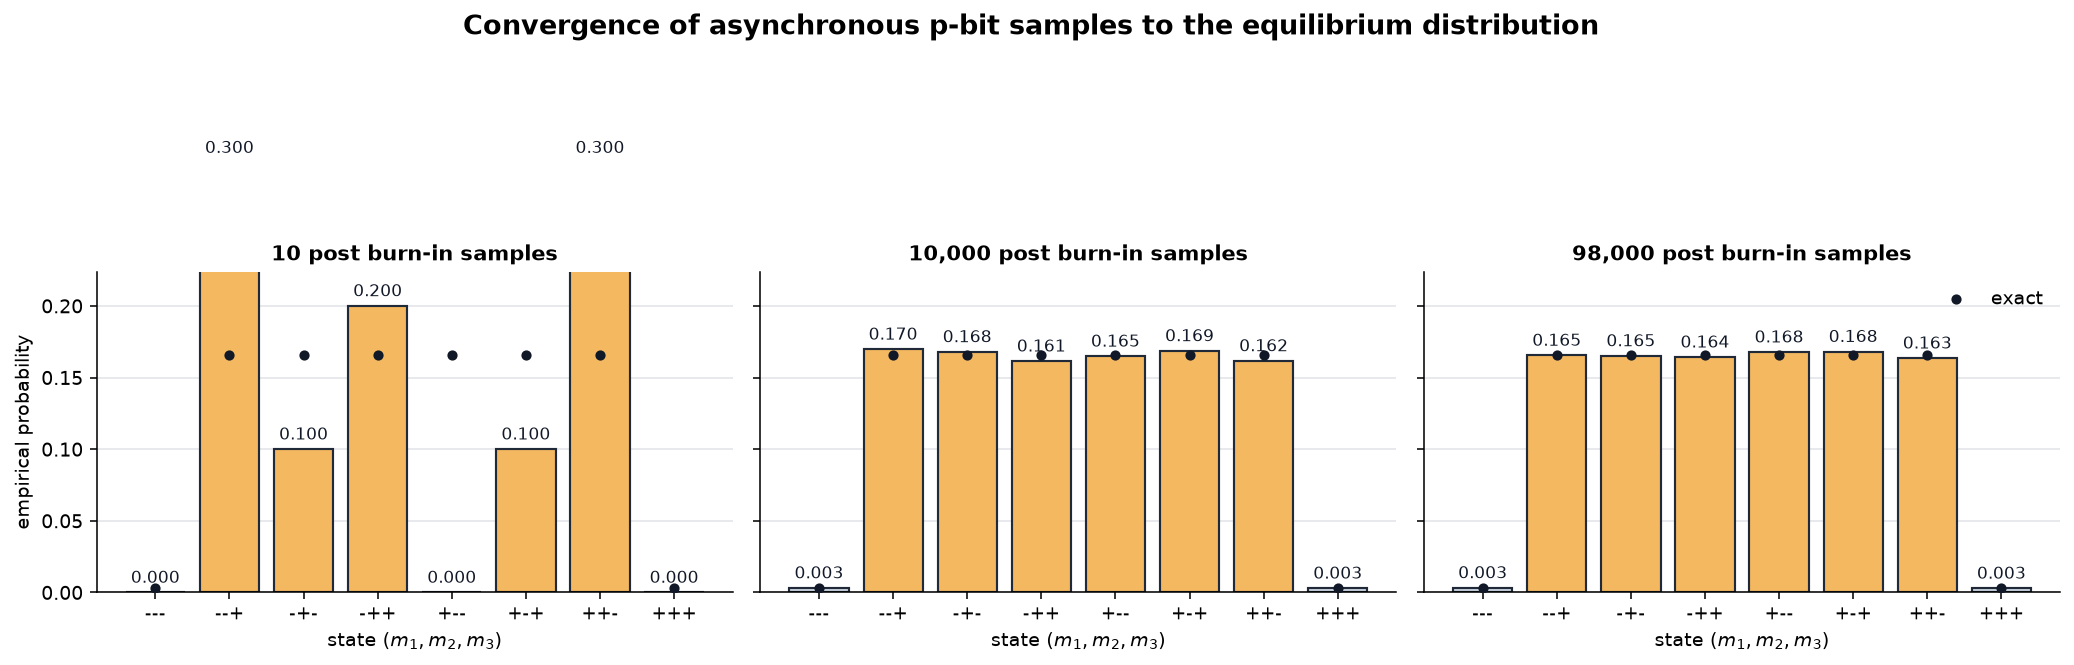

---: empirical pi=0.003184, exact pi=0.003034
--+: empirical pi=0.165429, exact pi=0.165655
-+-: empirical pi=0.165071, exact pi=0.165655
-++: empirical pi=0.164194, exact pi=0.165655
+--: empirical pi=0.167724, exact pi=0.165655
+-+: empirical pi=0.168061, exact pi=0.165655
++-: empirical pi=0.163480, exact pi=0.165655
+++: empirical pi=0.002857, exact pi=0.003034
[ 3 -1 -1 -1 -1 -1 -1  3]


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Fully frustrated three-pbit triangle: J_12 = J_13 = J_23 = -1
J = np.array([
    [0, -1, -1],
    [-1, 0, -1],
    [-1, -1, 0],
])

num_pbits = 3
num_sweeps = 100_000
burn_in = 2_000
rng = np.random.default_rng(7)

state = rng.choice([-1, 1], size=num_pbits)
samples = np.empty((num_sweeps, num_pbits), dtype=int)

for sweep in range(num_sweeps):
    for pbit in range(num_pbits):
        I_i = J[pbit] @ state
        prob_plus = (1 + np.tanh(I_i)) / 2
        state[pbit] = 1 if rng.random() < prob_plus else -1
    samples[sweep] = state

samples = samples[burn_in:]
states = np.array([
    [-1, -1, -1],
    [-1, -1,  1],
    [-1,  1, -1],
    [-1,  1,  1],
    [ 1, -1, -1],
    [ 1, -1,  1],
    [ 1,  1, -1],
    [ 1,  1,  1],
])
labels = [''.join('+' if x == 1 else '-' for x in state) for state in states]
colors = ['#cbd5e1' if label in ['---', '+++'] else '#f4b860' for label in labels]

# Exact probabilities, shown as black markers to make convergence visible.
energies = np.array([
    -sum(J[i, j] * state[i] * state[j] for i in range(3) for j in range(i + 1, 3))
    for state in states
])
exact_probabilities = np.exp(-energies)
exact_probabilities /= exact_probabilities.sum()

def empirical_probabilities(sample_block):
    counts = np.array([np.all(sample_block == state, axis=1).sum() for state in states])
    return counts / counts.sum()

snapshot_sizes = [1_0, 10_000, len(samples)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), dpi=140, sharey=True)

for ax, n in zip(axes, snapshot_sizes):
    probabilities = empirical_probabilities(samples[:n])
    bars = ax.bar(labels, probabilities, color=colors, edgecolor='#1f2937', linewidth=1.1)
    ax.scatter(labels, exact_probabilities, color='#111827', s=18, zorder=3, label='exact')

    for bar, probability in zip(bars, probabilities):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f'{probability:.3f}',
            ha='center',
            va='bottom',
            fontsize=8.5,
            color='#111827',
        )

    ax.set_title(f'{n:,} post burn-in samples', fontsize=11, weight='bold')
    ax.set_xlabel('state $(m_1,m_2,m_3)$')
    ax.grid(axis='y', color='#e5e7eb', linewidth=0.9)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)

axes[0].set_ylabel('empirical probability')
axes[0].set_ylim(0, exact_probabilities.max() * 1.35)
axes[-1].legend(frameon=False, loc='upper right')
fig.suptitle('Convergence of asynchronous p-bit samples to the equilibrium distribution', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

final_probabilities = empirical_probabilities(samples)
for label, probability, exact in zip(labels, final_probabilities, exact_probabilities):
    print(f'{label}: empirical pi={probability:.6f}, exact pi={exact:.6f}')

print(energies)
